In [ ]:
%pip install pandas matplotlib seaborn

# Netflix Titles — Exploratory Data Analysis

## Objetivo
Analizar el catálogo de Netflix para entender:
- Distribución por tipo (Movie / TV Show)
- Países más representados
- Géneros más frecuentes
- Evolución temporal
- Distribución de ratings

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [8]:
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Obtener numero de filas y columnas

In [9]:
df.shape

(8807, 12)

Que tipo es cada columna

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Cuantos nulos hay

In [11]:
df.isna().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

que tipo es date_added

In [12]:
df["date_added"].head()

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

Convertir date_added a tipo datetime

In [13]:
df["date_added"] =  pd.to_datetime(df["date_added"], errors="coerce")

In [16]:
df["date_added"].head()
df["date_added"].dtype

dtype('<M8[ns]')

Se crea un nuevo atributo "added_year"

In [19]:
df["added_year"] = df["date_added"].dt.year
df["added_year"].head()

0    2021.0
1    2021.0
2    2021.0
3    2021.0
4    2021.0
Name: added_year, dtype: float64

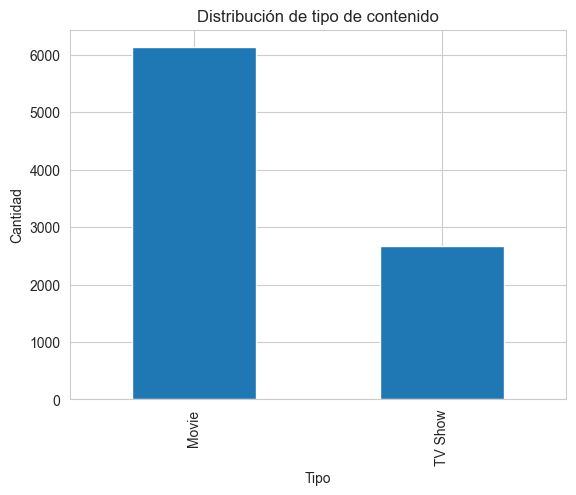

In [22]:
df["type"].value_counts().plot(kind="bar")
plt.title("Distribución de tipo de contenido")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

## Insight 1 — Predominio de películas

El catálogo de Netflix está compuesto mayoritariamente por películas (6131) frente a series (2676).

Esto indica que la estrategia histórica de la plataforma ha estado más orientada a contenido cinematográfico que a formato seriado.

In [23]:
df["added_year"].value_counts().sort_index()

added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

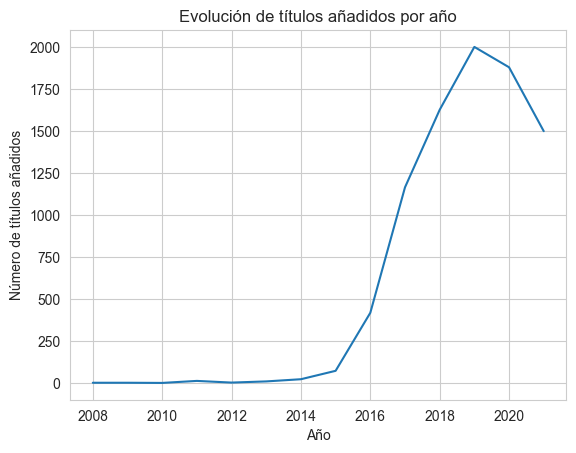

In [24]:
df["added_year"].value_counts().sort_index().plot(kind="line")
plt.title("Evolución de títulos añadidos por año")
plt.xlabel("Año")
plt.ylabel("Número de títulos añadidos")
plt.show()

## Insight 2 — Crecimiento hasta 2019 y descenso posterior

El número de títulos añadidos crece de forma sostenida hasta alcanzar su máximo en 2019.

A partir de 2020 se observa una disminución en la incorporación de nuevos títulos, posiblemente relacionada con:
- Impacto de la pandemia en la producción audiovisual
- Cambios estratégicos en inversión
- Mayor competencia en el sector del streaming

In [29]:
# Eliminamos filas donde country es NaN
country_series = df["country"].dropna()

# Separar por coma y expandir en múltiples filas
countries = country_series.str.split(", ", expand=True).stack()

# Contar países individuales
top_countries = countries.value_counts().head(10)

top_countries

United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

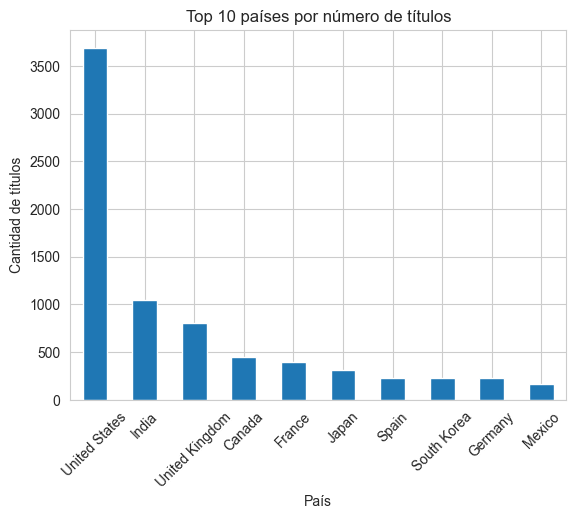

In [30]:
top_countries.plot(kind="bar")
plt.title("Top 10 países por número de títulos")
plt.xlabel("País")
plt.ylabel("Cantidad de títulos")
plt.xticks(rotation=45)
plt.show()

## Insight 3 — Distribución geográfica del catálogo

Estados Unidos lidera claramente el catálogo en número de títulos, seguido por India.

La presencia de India como segundo país refleja la importancia del mercado asiático para Netflix.

España aparece dentro del top 10, lo que indica una participación relevante del contenido español en la plataforma.

## Analisi de generos

In [32]:
genre_series = df["listed_in"]

genres = genre_series.str.split(", ", expand=True).stack()

top_genres = genres.value_counts().head(10)

top_genres

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

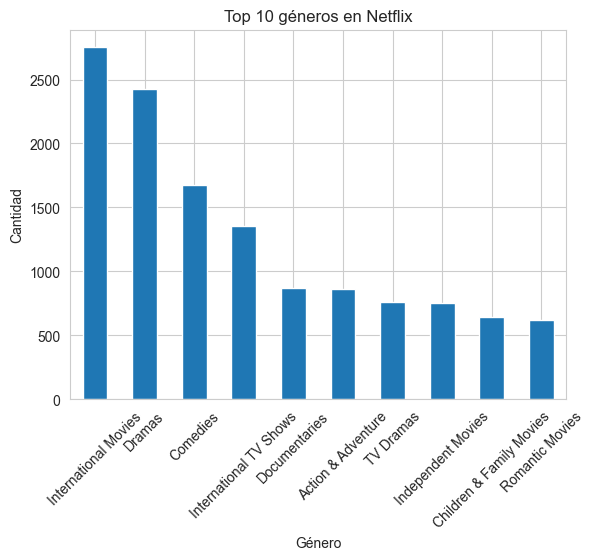

In [33]:
top_genres.plot(kind="bar")
plt.title("Top 10 géneros en Netflix")
plt.xlabel("Género")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

## Insight 4 — Predominio de contenido internacional y dramático

El género más frecuente en el catálogo es "International Movies", lo que refleja la estrategia global de Netflix.

Entre los géneros clásicos, predominan los dramas, seguidos por las comedias, lo que sugiere una fuerte orientación hacia contenido narrativo y de amplio consumo.

## Analisis de Ratings

In [35]:
df["rating"].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

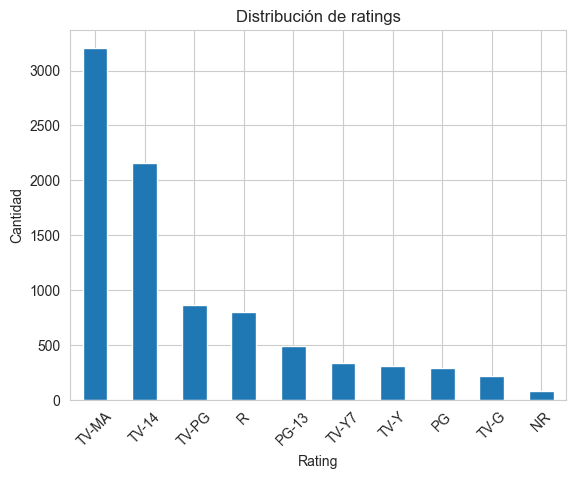

In [36]:
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

## Insight 5 — Orientación hacia público adulto

El rating más frecuente es TV-MA, seguido por TV-14.

Esto indica que el catálogo está mayoritariamente orientado a público adolescente y adulto, más que a contenido infantil o familiar.

In [40]:
movies_df = df[df["type"] == "Movie"]

movies_df.shape

(6131, 13)

In [ ]:
# Eliminar filas donde duration sea nulo
movies_df = movies_df.dropna(subset=["dur"])

movies_df["duration_minutes"] = movies_df["duration"].str.split(" ").str[0].astype(int)

ValueError: cannot convert float NaN to integer

# Conclusiones finales

- El catálogo está dominado por películas (~70%).
- El crecimiento de incorporación alcanza su pico en 2019 y desciende posteriormente.
- Estados Unidos lidera en número de títulos, seguido por India.
- Predominan géneros dramáticos e internacionales.
- La mayoría del contenido está orientado a público adulto.